# EncoderX AI/ML Task 1 — Image Classification using CNN

**Dataset:** CIFAR-10  
**Framework:** TensorFlow / Keras  
**Domain:** AI / Machine Learning  
**Task:** Image Classification

### **1. Project Overview**

> Image classification is one of the most fundamental applications of Artificial Intelligence and Computer Vision.
In this project, we will collect or select an image dataset, preprocess the images, train a Convolutional Neural  Network (CNN), and evaluate its performance using appropriate classification metrics.






### **2. Import Libraries**

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### **3. Dataset Loading**

In [ ]:

#____ import libraries
from tensorflow.keras.datasets import cifar10
import numpy as np

In [ ]:
#___ Mount Google Drive
import os
from google.colab import drive
import numpy as np

drive.mount('/content/drive')

#____define Folder where we will permanently store CIFAR-10
data_dir = '/content/drive/MyDrive/EncoderX_AI/ML/CIFAR-10'
os.makedirs(data_dir, exist_ok=True)

print("Drive mounted successfully.")
print("Dataset folder:", data_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully.
Dataset folder: /content/drive/MyDrive/EncoderX_AI/ML/CIFAR-10


In [ ]:
#___load dataset ----- (run only once)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Dataset loaded successfully!")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

   417792/170498071 ━━━━━━━━━━━━━━━━━━━━ 34:26 12us/step

KeyboardInterrupt: 

In [ ]:
#___ save it permanently to drive -----  (run only once)
np.save(os.path.join(data_dir, 'x_train.npy'), x_train)
np.save(os.path.join(data_dir, 'y_train.npy'), y_train)
np.save(os.path.join(data_dir, 'x_test.npy'), x_test)
np.save(os.path.join(data_dir, 'y_test.npy'), y_test)

print("✅ CIFAR-10 saved permanently to Google Drive.")

✅ CIFAR-10 saved permanently to Google Drive.


In [ ]:
#____ Load data from drive
x_train = np.load(os.path.join(data_dir, 'x_train.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
x_test = np.load(os.path.join(data_dir, 'x_test.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

print("✅ CIFAR-10 loaded from Google Drive!")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

✅ CIFAR-10 loaded from Google Drive!
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


**IMAGE            ANSWER**

---


x_train  ─→  y_train


x_test   ─→  y_test*

In [ ]:


#____ checking dataset shapes
print("Training images:", x_train.shape)
print("Trainng Labels:", y_train.shape)

print("Testing Images:",x_test.shape)
print("Testing Labels:",y_test.shape)

Training images: (50000, 32, 32, 3)
Trainng Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


In [ ]:

#____ checking image dimensions (height, width, RDB channel)
print("One image dimensions:", x_train[0].shape)


One image dimensions: (32, 32, 3)


In [ ]:



#____ checcking image labels
print("One image Label:", y_train[0].shape)

One image Label: (1,)


In [ ]:


#___ defining classes
import numpy as np
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

#____ checking no of classes
len(class_names)

10

In [ ]:


set(y_train.flatten())

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

In [ ]:


#___ classes name
print("Classes names:",class_names)

#___ number with class names
for i,name in enumerate(class_names):
  print(i, "-", name)

#___ one image with class label
print("Image index:",y_train[3])
print("Image label:",y_train[3][0])
print("Image class:",class_names[y_train[3][0]])

Classes names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
0 - airplane
1 - automobile
2 - bird
3 - cat
4 - deer
5 - dog
6 - frog
7 - horse
8 - ship
9 - truck
Image index: [4]
Image label: 4
Image class: deer


In [ ]:
#___ checking class distribution
import numpy as np

for i in range(10):
  count = np.sum(y_train==i)
  print(class_names[i],":", count)


airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


### **4. Exploratory Data Analysis**

**Visualize sample:**

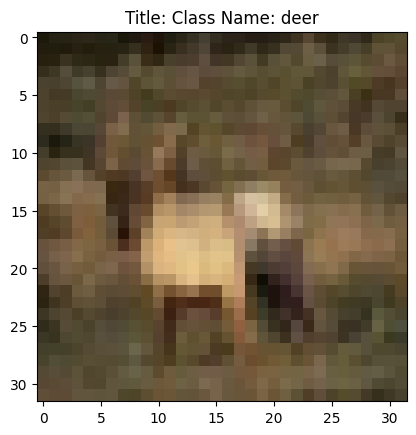

In [ ]:

import matplotlib.pyplot as plt

# show one image
plt.imshow(x_train[3])
plt.title(f"Title: Class Name: {class_names[y_train[3][0]]}")
plt.show()

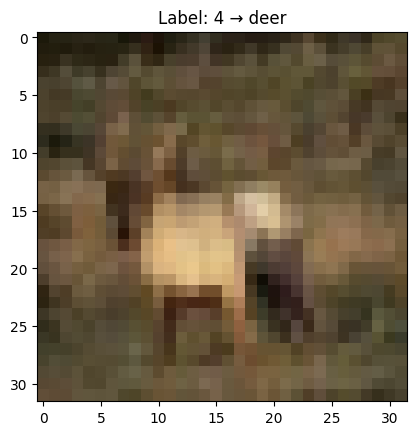

In [ ]:
# label & class name
plt.imshow(x_train[3])
label = y_train[3][0]
plt.title(f"Label: {label} → {class_names[label]}")
plt.show()


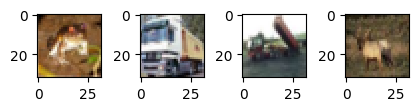

In [ ]:
#__ multiple sample images
plt.subplot(5, 5, 1)  #- subplot(nrow, ncolumn, index/position inside grid)
plt.imshow(x_train[0])

plt.subplot(5, 5, 2)
plt.imshow(x_train[1])

plt.subplot(5, 5, 3)
plt.imshow(x_train[2])

plt.subplot(5, 5, 4)
plt.imshow(x_train[3])

plt.show()

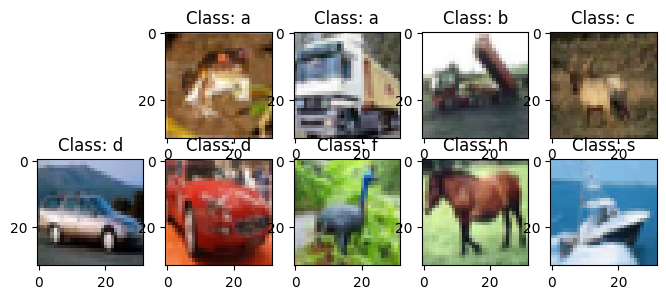

In [ ]:
#__ multiple images using loop

# creating canvas 8by8
plt.figure(figsize=(8,8))

for i  in range(9):    ## 10 classes
  plt.subplot(5, 5, i+2)
  plt.imshow(x_train[i])
  plt.title(f"Class: {class_names[i][0]}")

plt.show()


[np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000), np.int64(5000)]


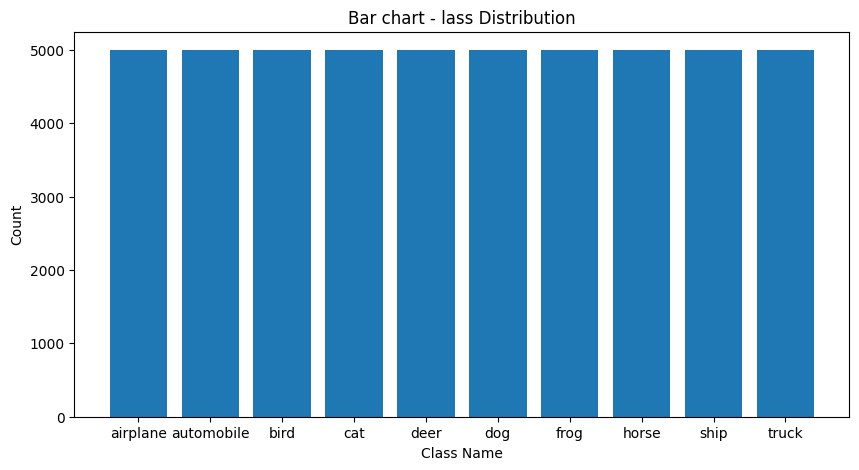

In [ ]:
#___ Bar chart Visualization
class_counts  = []
for i in range(10):
  count = np.sum(y_train== i)
  class_counts.append(count)

print(class_counts)

#___ chart creation
plt.figure(figsize=(10,5))
plt.bar(class_names, class_counts)
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.title("Bar chart - lass Distribution")
plt.show()


### **5. Data Preprocessing**

In [ ]:
#___ current values of pixels
print("Minimum pixel values:",x_train.min())
print("Maximum pixel values:",x_train.max())

Minimum pixel values: 0
Maximum pixel values: 255


**Normalization:**

In [ ]:
#___ normalize the images - (just training & testing images not labels)
x_train = x_train/255
x_test = x_test/255

#___ verifying normalization values
print("Minimum pixel values:", x_train.min())
print("Maximum pixel values:", x_train.max())

Minimum pixel values: 0.0
Maximum pixel values: 1.0


**Creating Training & validation dataset:**

In [ ]:
#___ Creating the splitting datasets
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val =  train_test_split(x_train, y_train, test_size=0.1, random_state = 42)

#__ verifying splitting datset
print("Training iamges",x_train.shape)
print("Training labels",y_train.shape)
print("Validation images",x_val.shape)
print("Validation labels",y_val.shape)


Training iamges (45000, 32, 32, 3)
Training labels (45000, 1)
Validation images (5000, 32, 32, 3)
Validation labels (5000, 1)


In [ ]:
#__ verifying normalization after splitting
print("Training range:", x_train.min(), "to", x_train.max())
print("Validation range:", x_val.min(), "to", x_val.max())
print("Testing range:", x_test.min(), "to", x_test.max())

Training range: 0.0 to 1.0
Validation range: 0.0 to 1.0
Testing range: 0.0 to 1.0


**Verfiying  Training & validation labels:**


In [ ]:
print("Training Labels: ",y_train[0][0])
print("Training Class: ", class_names[y_train[0][0]])

print("Validation Labels: ",y_val[0][0])
print("Validation Class: ", class_names[y_val[0][0]])

Training Labels:  3
Training Class:  cat
Validation Labels:  7
Validation Class:  horse


### **6. Data Augmentation**

**RandomFlip Layer:**

The augmentation layer can randomly decide whether to flip each image when the layer is applied during training.

In [ ]:
#___ importing Augmentation layer
from tensorflow.keras import layers

In [ ]:
#____ Creating 1st Augmentation layer
data_aug = layers.RandomFlip("horizontal")


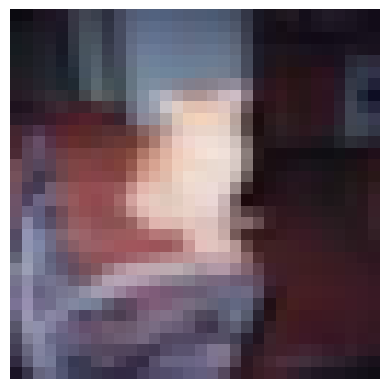

In [ ]:
#___ Apply randomFLip to one Image
image = x_train[0]
augmented_img =  data_aug(image)
plt.imshow(augmented_img)
plt.axis("off")
plt.show()

**Comparing Original VS Flipped Image:**



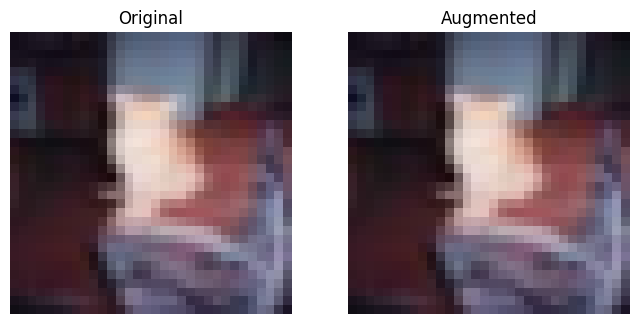

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_train[0])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(data_aug(x_train[0]))
plt.title("Augmented")
plt.axis("off")

plt.show()

### **7. Building/Designing CNN Model Architecture**
 Conv2D   -> ReLU  -> Pooling  ->  Fully Connected

**1. BUild CNN Model**

In [ ]:
from tensorflow.keras import layers, models
model = tf.keras.models.Sequential([
    # input layer
    layers.Input(shape = (32,32,3)),    # tells model about receiving images

    # 1st conv2D layer block
    layers.Conv2D(32, (3,3), padding = "same", activation =  "relu"),
    # maxpool layer
    layers.MaxPool2D(pool_size = (2,2)),

    # 2nd conv2D layer block
    layers.Conv2D(64, (3,3), padding = "same", activation =  "relu"),
    # maxpool layer
    layers.MaxPool2D(pool_size = (2,2)),

    # Flatten layer
    layers.Flatten(),

    # hidden layers
    layers.Dense(128, activation = "relu"),   # 128 neurons

    # output layers
    layers.Dense(10, activation = "softmax")  # one for each CIFAR-10 class - output values that softmax convert thm into classes
])

In [ ]:
model.summary()
# parameters = 896
# (kernel height × kernel width × input channels + bias) × number of filters

# Input Image
# 32 × 32 × 3
#    ↓
# Conv2D
# 32 filters
# 3 × 3 kernel
# same padding
# ReLU
#     ↓
# Output
# 32 × 32 × 32
#      ↓
#896 trainable parameters

#__ maxpooling - 0 parameters: cuz maxooling reduce size not learn parameters

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### **Compile the Model:**
tensoeflow - gives option to optimize weights using algorithms (like adam)

*   Optimizer: update weights
*   loss: how wrong the prediction is
*   mertics: model performance






In [ ]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",   # for classififction:interger labels[0,1,2,---,9]
    metrics = ["accuracy"]
)

### **8. Model Training**




In [ ]:
history = model.fit(
          x_train,
          y_train,
          epochs = 20,
          batch_size = 32,
          validation_data = (x_val, y_val)
      )

# t_acc = increase at 96% to 98%  -----\
# v_acc = stable arond 67%        -----/   Overfitting  - best at training data but low at validation/unseen data

# same diff in t_loss = 0.1 to 0.04
# v_loss = 2.06 to 3.9

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4906 - loss: 1.4209 - val_accuracy: 0.5876 - val_loss: 1.1468
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6284 - loss: 1.0543 - val_accuracy: 0.6412 - val_loss: 0.9944
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6840 - loss: 0.9027 - val_accuracy: 0.6726 - val_loss: 0.9353
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7210 - loss: 0.7976 - val_accuracy: 0.6818 - val_loss: 0.9224
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7505 - loss: 0.7064 - val_accuracy: 0.7042 - val_loss: 0.8755
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7782 - loss: 0.6249 - val_accuracy: 0.7084 - val_loss: 0.8777
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8058 - loss: 0.5494 - val_accuracy: 0.7026 - val_loss: 0.9199
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8285 - loss: 0.4838 -

### **9. Training Visualization**
Training Accuracy vs Validation Accuracy

Training Loss vs Validation Loss

In [ ]:
history.history.keys()

# each dict has 20  values
# 'accuracy': [20values],
# 'loss': [20 values] ------

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

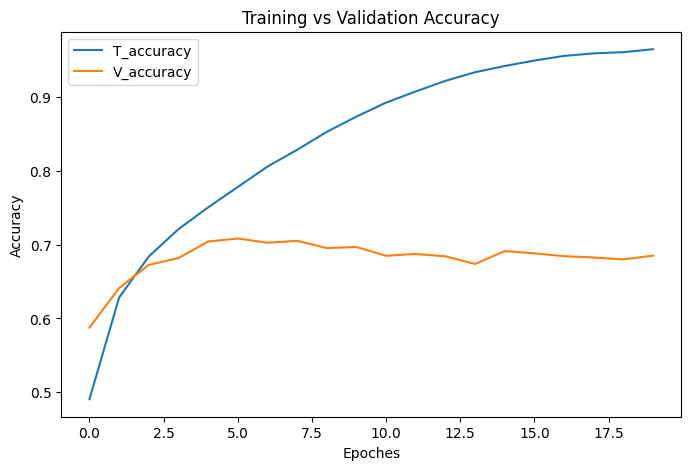

In [ ]:
#___ training vs validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))

plt.plot(history.history["accuracy"], label = "T_accuracy" )
plt.plot(history.history["val_accuracy"], label = "V_accuracy" )

plt.xlabel("Epoches")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


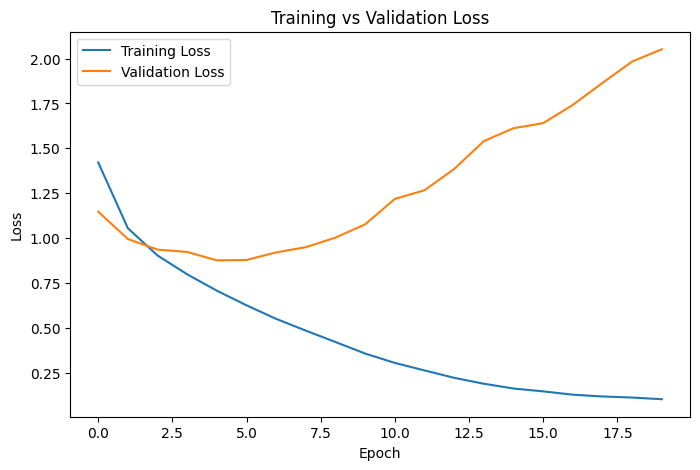

In [ ]:
#___ trainning & validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### **10. Model Evaluation**





**Testing using unseeen data:**

In [ ]:
#___ testing using unseen/testing dataset
test_loss, test_accuracy =  model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6791 - loss: 2.1190
Test Loss: 2.1189675331115723
Test Accuracy: 0.679099977016449


**Generate Prediction:**

In [ ]:
# ___ getting proabilites of images
y_pred_prob = model.predict(x_test)
print(y_pred_prob)
print(y_pred_prob.shape)


### (10,000, 10)  - 10k images and 10 proabilites vectors of 1 image
### find highest proabilites vector -> Class index

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[5.8494063e-09 3.8682739e-08 2.4646206e-14 ... 1.5864638e-17
  7.4461173e-06 8.7112306e-10]
 [3.9707567e-04 9.9915636e-01 7.4129334e-15 ... 1.4586280e-18
  4.4659109e-04 7.6879481e-09]
 [8.5784328e-01 9.0452231e-04 3.3597098e-04 ... 2.8238468e-02
  9.2519484e-02 1.7586121e-03]
 ...
 [1.5363911e-14 6.0771971e-20 9.8787236e-09 ... 2.2941573e-12
  3.8984479e-11 1.9945198e-14]
 [2.4952229e-02 7.3418671e-01 1.0831562e-04 ... 2.9528885e-10
  1.0608566e-02 3.7936581e-11]
 [2.1518345e-14 4.3775709e-13 8.9918734e-10 ... 9.9999905e-01
  7.8851210e-17 1.7700508e-14]]
(10000, 10)


**1 predicted class for each(10,000) images insted of 10 proabilites of each images:**




In [ ]:
y_pred = np.argmax(y_pred_prob, axis = 1)
print("Indexes of  high predicted classes:",y_pred)
print("Shapes of predicted classes:", y_pred.shape)
print("Predicted class high-indexes:", y_pred[:10])
y_pred[0]

Indexes: [3 1 0 ... 5 1 7]
Shapes of predicted classes: (10000,)
Predicted class indexes: [3 1 0 0 6 6 1 2 3 1]


np.int64(3)

**Class indexes -> class Labels:**




In [ ]:
print("Class Names: ", class_names)

#Predicted Classes
y_pred_labels = [class_names[i] for i in y_pred]
print("Predicted Classes: ", y_pred_labels[:10])

class_names[y_pred[0]]





Class Names:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Predicted Classes:  ['cat', 'automobile', 'airplane', 'airplane', 'frog', 'frog', 'automobile', 'bird', 'cat', 'automobile']


'cat'

**Predicted Labels vs Actual Labels :**

In [ ]:
for i in range(10):
    print(
        f"Image {i+1}: "
        f"Actual = {class_names[y_test[i][0]]}, "
        f"Predicted = {class_names[y_pred[i]]}"
    )


Image 1: Actual = cat, Predicted = cat
Image 2: Actual = ship, Predicted = automobile
Image 3: Actual = ship, Predicted = airplane
Image 4: Actual = airplane, Predicted = airplane
Image 5: Actual = frog, Predicted = frog
Image 6: Actual = frog, Predicted = frog
Image 7: Actual = automobile, Predicted = automobile
Image 8: Actual = frog, Predicted = bird
Image 9: Actual = cat, Predicted = cat
Image 10: Actual = automobile, Predicted = automobile


### **11. Confusion Matrix**

**Calculate Accuracy:**

In [ ]:
print(y_test.shape)
print(y_pred.shape)

# same shapes
print(y_test.flatten().shape)
print(y_pred.shape)

# both contain now, one class label for each of the 10,000 test images.

(10000, 1)
(10000,)
(10000,)
(10000,)


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#____ accuracy
accuracy = accuracy_score(y_test.flatten(), y_pred)   # training label, testing label(index)
print("ACCURACY:", accuracy)
print("Accuray_%:", accuracy*100)
print()

#___precision
precision = precision_score(y_test.flatten(), y_pred, average = "weighted")
print("PRECISION:", precision)
print("Precision_%:", precision * 100)
print()


#___recall
recall = recall_score(y_test.flatten(), y_pred, average = "weighted")
print("RECALL:", recall)
print("Recall_%:", recall * 100)
print()

#____ f1
f1 = f1_score(y_test.flatten(),y_pred,average='weighted')
print("F1-Score:", f1)
print("F1-Score (%):", f1 * 100)

ACCURACY: 0.6791
Accuray_%: 67.91

PRECISION: 0.6839302797326563
Precision_%: 68.39302797326563

RECALL: 0.6791
Recall_%: 67.91

F1-Score: 0.6804216687103213
F1-Score (%): 68.04216687103212


### **Classification report:**

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test.flatten(),
    y_pred,
    target_names=class_names
)

print(report)

#support: how many actal test samples/images belong to that class

              precision    recall  f1-score   support

    airplane       0.71      0.76      0.73      1000
  automobile       0.83      0.78      0.80      1000
        bird       0.56      0.59      0.57      1000
         cat       0.45      0.51      0.48      1000
        deer       0.63      0.58      0.60      1000
         dog       0.60      0.55      0.57      1000
        frog       0.70      0.78      0.74      1000
       horse       0.78      0.68      0.73      1000
        ship       0.80      0.80      0.80      1000
       truck       0.78      0.76      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



**CONFUSION METRIX:**

> Add blockquote



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test.flatten(), y_pred)
print(cm)

[[758  13  42  26  19   8  18  13  63  40]
 [ 28 776  17  15   3   6  12   8  44  91]
 [ 71   3 588  94  85  42  71  26   9  11]
 [ 33  10  88 513  52 171  90  22  10  11]
 [ 29   3 107  90 582  44  73  59   8   5]
 [ 11   6  69 211  54 551  35  46  10   7]
 [  8   7  50  72  37  23 777   8  10   8]
 [ 21   3  49  79  74  61  10 682   5  16]
 [ 66  32  22  20  12   8   9   4 800  27]
 [ 40  81  15  24   6  10  12  12  36 764]]


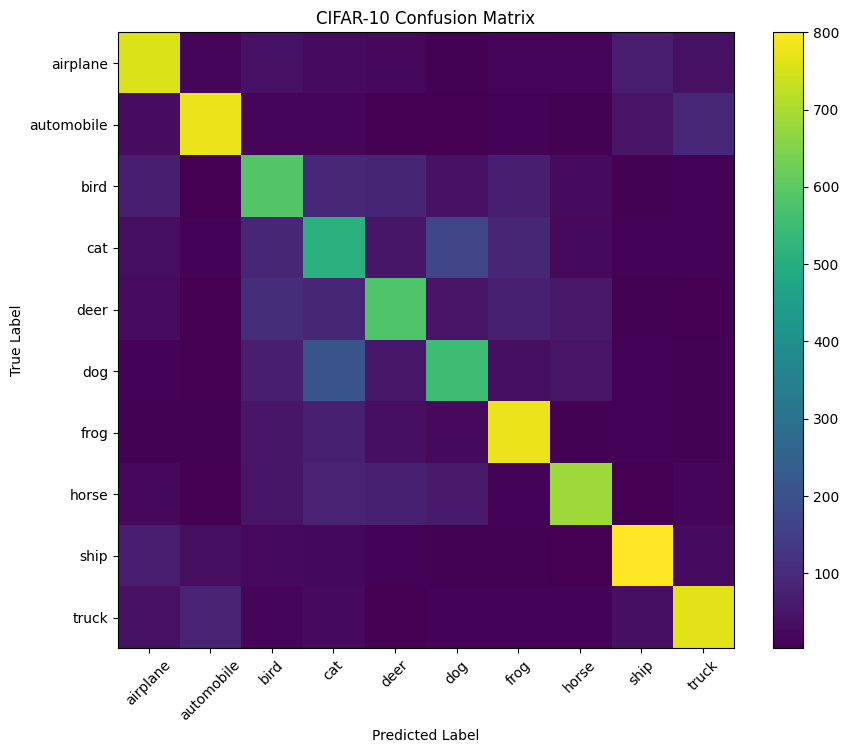

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

<Figure size 1000x800 with 0 Axes>

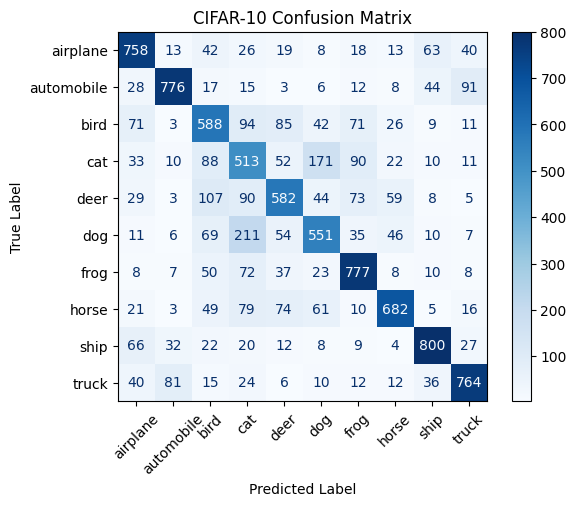

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("CIFAR-10 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**Normalized Confusion Metrix:**

Raw confusion matrix → number of images

Normalized confusion matrix → proportion/percentage of images

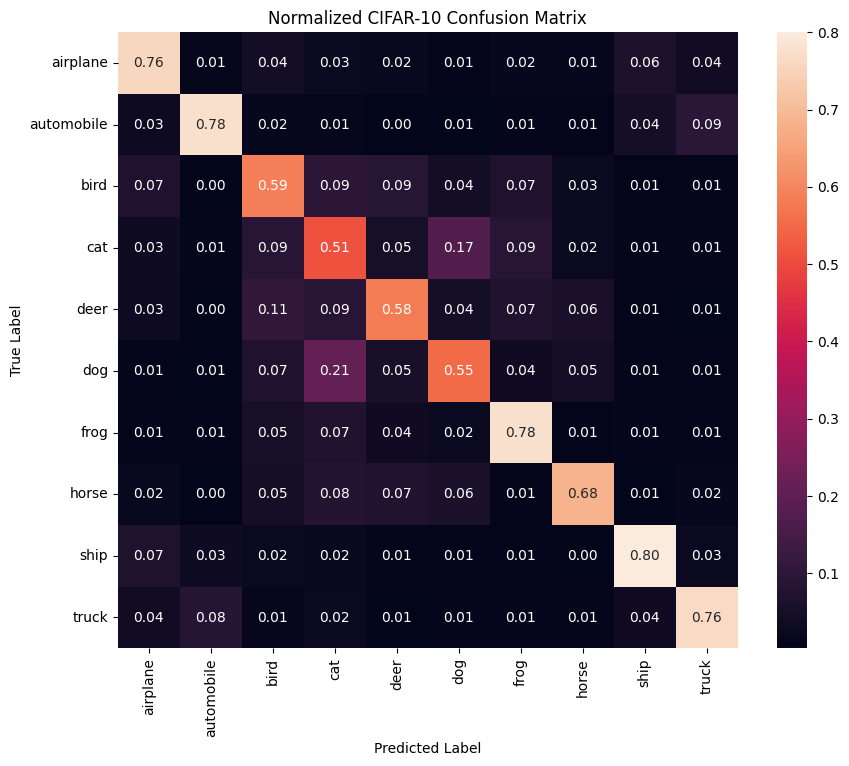

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_normalized = confusion_matrix(
    y_test.flatten(),
    y_pred,
    normalize='true'
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized CIFAR-10 Confusion Matrix")

plt.show()


### **12. Error Analysis**

**1. Compare Training and Validartion accuracy**





In [ ]:
#__ training is stored in'history'(model.fit ---)

print("Training Accuracy:", history.history["accuracy"][-1])
print("Validation Accurwcy:", history.history["val_accuracy"][-1])


Training Accuracy: 0.9648222327232361
Validation Accurwcy: 0.6851999759674072


**Error 01:**


> trainig accuracy = 97%

> validation accuracy = 68%

> 97-68 = 28% points gap

> ***Model is  Overfitting***

**2. Analyze Incorrect Predictions:**

np.where() returns the indices where a condition is true.

[0] extracts the index array from the tuple returned by np.where().

In [ ]:
incorrect_indexes = np.where(y_test.flatten() != y_pred)[0]

print("Total Incorrect Predictions:", len(incorrect_indexes))
print("1st 20 incorrect indexces:", incorrect_indexes[:20])

Total Incorrect Predictions: 3209
1st 20 incorrect indexces: [ 1  2  7 20 21 24 25 31 32 33 35 37 46 47 52 54 56 57 58 65]


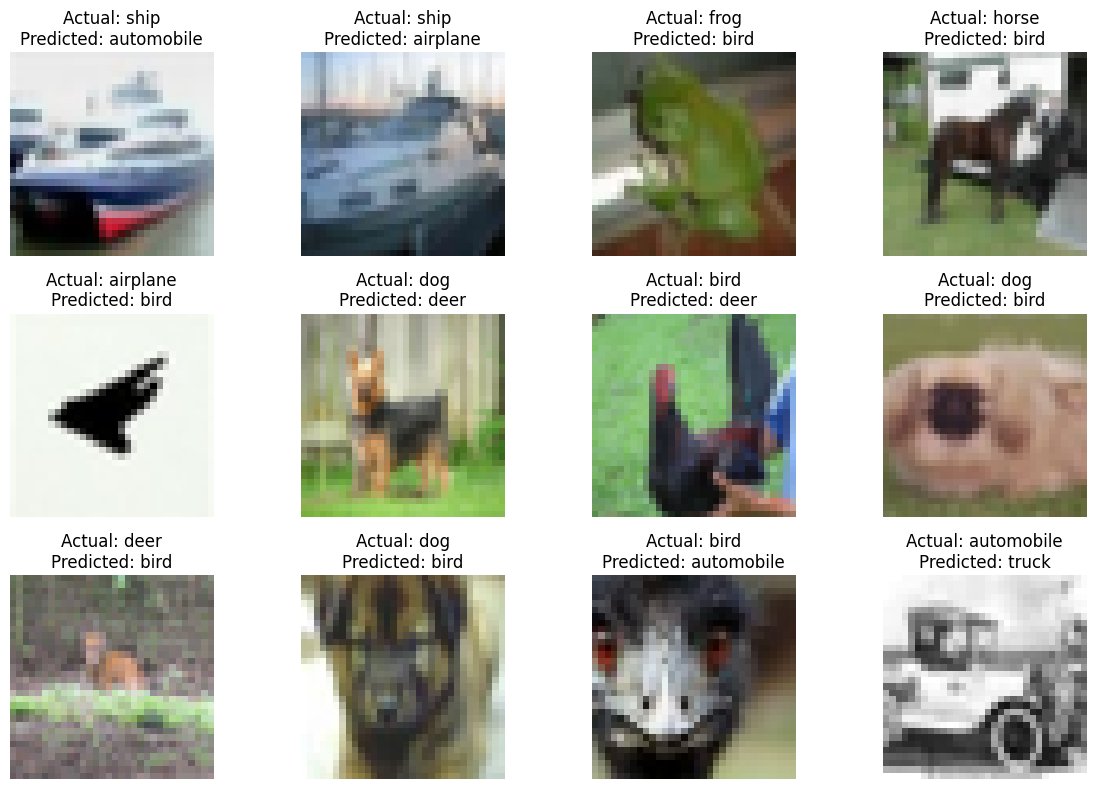

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect_indexes[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[y_test[index][0]]
    predicted = class_names[y_pred[index]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**3. Count the most common Mistakes**

what pattern do we see in mistakes

In [ ]:
from collections import Counter

error_pairs = Counter((class_names[y_test[index][0]], class_names[y_pred[index]]) for index in incorrect_indexes)

print("Most common errors:")

for pair, count in error_pairs.most_common(10):
    print(f"{pair[0]} → {pair[1]} : {count}")

Most common errors:
dog → cat : 211
cat → dog : 171
deer → bird : 107
bird → cat : 94
automobile → truck : 91
cat → frog : 90
deer → cat : 90
cat → bird : 88
bird → deer : 85
truck → automobile : 81


**4. identify the single most problematic class overall**

In [ ]:
actual_error_counts = Counter(
    class_names[y_test[index][0]] for index in incorrect_indexes
)

print("Errors by actual class:")

for class_name, count in actual_error_counts.most_common():
    print(f"{class_name}: {count}")

    ### cat, dog, deer are the highest  no of misclassification

Errors by actual class:
cat: 487
dog: 449
deer: 418
bird: 412
horse: 318
airplane: 242
truck: 236
automobile: 224
frog: 223
ship: 200



### **13. Model Improvement**
Building improved model by  adding data augmentation

**Problem:** Overfitting/ poor generalization

**1st Improvement:** Integrating Data Augmentation in CNN training

**i.  Building Imporved Model:**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Adding augmentation
data_aug = keras.Sequential([layers.RandomFlip("horizontal")])

#Impoved CNN
improved_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_aug,
    layers.Conv2D(32, (3,3),  padding = "same", activation = "relu"),
    layers.MaxPool2D(2, 2),

    layers.Conv2D(64, (3,3),  padding = "same", activation = "relu"),
    layers.MaxPool2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dense(10, activation = "softmax")
])

In [ ]:
#____imporved model summary - check architecture
improved_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

**ii. Compile Improved Model:**

In [ ]:
improved_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

**iii.  Train Improved Model:**


In [ ]:
improved_history = improved_model.fit(
          x_train,
          y_train,
          epochs = 20,
          batch_size = 32,
          validation_data = (x_val, y_val)
      )

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4996 - loss: 1.3986 - val_accuracy: 0.5758 - val_loss: 1.1859
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6309 - loss: 1.0521 - val_accuracy: 0.6414 - val_loss: 0.9993
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6769 - loss: 0.9276 - val_accuracy: 0.6596 - val_loss: 0.9655
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7050 - loss: 0.8405 - val_accuracy: 0.6848 - val_loss: 0.8831
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7280 - loss: 0.7812 - val_accuracy: 0.6854 - val_loss: 0.9041
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7454 - loss: 0.7261 - val_accuracy: 0.7064 - val_loss: 0.8258
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7607 - loss: 0.6834 - val_accuracy: 0.7022 - val_loss: 0.8837
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7730 - loss: 0.6448 

| Metric              |   Baseline | With Augmentation |
| ------------------- | ---------: | ----------------: |
| Training Accuracy   | **97.14%** |        **89.71%** |
| Validation Accuracy | **68.88%** |        **73.04%** |
| Train–Val Gap       | **28.26%** |        **16.67%** |


**iv. Evaluate Improved Model:**

In [ ]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(x_test, y_test)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)
print("Improved Test Accuracy (%):", improved_test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7200 - loss: 1.0760
Improved Test Loss: 1.0759931802749634
Improved Test Accuracy: 0.7200000286102295
Improved Test Accuracy (%): 72.00000286102295


In [ ]:
#___ testing using unseen/testing dataset

test_loss, test_accuracy =  improved_model.evaluate(x_test,y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7200 - loss: 1.0760
Test Loss: 1.0759931802749634
Test Accuracy: 0.7200000286102295


| Metric              |   Baseline |   Improved |
| ------------------- | ---------: | ---------: |
| Training Accuracy   |     97.14% |     89.71% |
| Validation Accuracy |     68.88% |     73.04% |
| **Test Accuracy**   | **68.29%** | **72.00%** |


In [ ]:
#____ Generate Predictions

improved_y_pred_probs = improved_model.predict(x_test)

improved_y_pred = np.argmax(
    improved_y_pred_probs,
    axis=1
)

print("Prediction probabilities shape:", improved_y_pred_probs.shape)
print("Predicted labels shape:", improved_y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediction probabilities shape: (10000, 10)
Predicted labels shape: (10000,)


**v. Precision, Recall, f1 - Classification Report:**

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Precision
improved_precision = precision_score(
    y_test.flatten(),
    improved_y_pred,
    average='weighted'
)

# Recall
improved_recall = recall_score(
    y_test.flatten(),
    improved_y_pred,
    average='weighted'
)

# F1-Score
improved_f1 = f1_score(
    y_test.flatten(),
    improved_y_pred,
    average='weighted'
)

# Print overall metrics
print("Improved Precision:", improved_precision)
print("Improved Precision (%):", improved_precision * 100)

print("\nImproved Recall:", improved_recall)
print("Improved Recall (%):", improved_recall * 100)

print("\nImproved F1-Score:", improved_f1)
print("Improved F1-Score (%):", improved_f1 * 100)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test.flatten(),
        improved_y_pred,
        target_names=class_names
    )
)

Improved Precision: 0.7239470350917803
Improved Precision (%): 72.39470350917803

Improved Recall: 0.72
Improved Recall (%): 72.0

Improved F1-Score: 0.719062120469671
Improved F1-Score (%): 71.9062120469671

Classification Report:
              precision    recall  f1-score   support

    airplane       0.64      0.85      0.73      1000
  automobile       0.85      0.82      0.83      1000
        bird       0.66      0.61      0.63      1000
         cat       0.54      0.54      0.54      1000
        deer       0.72      0.65      0.68      1000
         dog       0.69      0.57      0.63      1000
        frog       0.81      0.77      0.79      1000
       horse       0.71      0.80      0.75      1000
        ship       0.86      0.76      0.81      1000
       truck       0.78      0.83      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



**Baseline:**

97.14% train

68.88% validation

→ 28.26 pp gap

**Improved:**

89.71% train

73.04% validation

→ 16.67 pp gap

| Metric                  | Baseline CNN | Improved CNN + RandomFlip |       Change |
| ----------------------- | -----------: | ------------------------: | -----------: |
| **Test Accuracy**       |       67.91% |                **72.00%** | **+4.09 pp** |
| **Precision**           |       68.39% |                **72.39%** | **+4.00 pp** |
| **Recall**              |       67.91% |                **72.00%** | **+4.09 pp** |
| **F1-Score**            |       68.04% |                **71.91%** | **+3.87 pp** |
| **Validation Accuracy** |       68.88% |                **73.04%** | **+4.16 pp** |
| **Training Accuracy**   |       97.14% |                    89.71% |     −7.43 pp |


### **Saved Improved Model:**

In [ ]:
# Save the final improved CNN model

model_path = "/content/drive/MyDrive/EncoderX_AI/ML/CIFAR-10/final_cifar10_cnn.keras"

improved_model.save(model_path)

print("Final model saved successfully!")
print("Model path:", model_path)

Final model saved successfully!
Model path: /content/drive/MyDrive/EncoderX_AI/ML/CIFAR-10/final_cifar10_cnn.keras


In [ ]:
# Verify that the saved model file exists

import os

if os.path.exists(model_path):
    print("Model file verified successfully!")
    print("File size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")
else:
    print("Model file not found!")

✅ Model file verified successfully!
File size: 6.28 MB


In [ ]:
# Load the saved final model

from tensorflow import keras

loaded_model = keras.models.load_model(model_path)

print("✅ Saved model loaded successfully!")
loaded_model.summary()

✅ Saved model loaded successfully!


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,635,296 (6.24 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,090,198 (4.16 MB)


### **14. Final Results**



### **Baseline vs Improved Model**

The baseline CNN was compared with an improved CNN using RandomFlip data augmentation.

| Metric | Baseline CNN | Improved CNN | Improvement |
|---|---:|---:|---:|
| Validation Accuracy | 68.88% | 73.04% | +4.16% |
| Test Accuracy | 67.91% | 72.00% | +4.09% |
| Precision | 68.39% | 72.39% | +4.00% |
| Recall | 67.91% | 72.00% | +4.09% |
| F1-Score | 68.04% | 71.91% | +3.87% |

### **Overfitting Comparison**

| Metric | Baseline CNN | Improved CNN |
|---|---:|---:|
| Training Accuracy | 97.14% | 89.71% |
| Validation Accuracy | 68.88% | 73.04% |
| Train-Validation Gap | 28.26% | 16.67% |

The improved model achieved better performance on unseen data while reducing the gap between training and validation accuracy.


### **15. Conclusion**

## 15. Conclusion

- This project developed a CNN-based image classification model for the CIFAR-10 dataset.

- The baseline CNN achieved a test accuracy of 67.91%. Error analysis showed significant overfitting, with a large gap between training and validation accuracy. The confusion matrix also showed that visually similar classes, particularly cat, dog, bird, and deer, were more difficult for the model to classify correctly.

- To address the overfitting problem, RandomFlip data augmentation was integrated into the CNN training pipeline. After retraining, the improved model achieved 72.00% test accuracy, with Precision of 72.39%, Recall of 72.00%, and F1-Score of 71.91%.

- The train-validation gap decreased from 28.26 percentage points to 16.67 percentage points, indicating improved generalization.

Overall, the experiment demonstrated that data augmentation helped the CNN perform better on unseen CIFAR-10 images and reduced overfitting.



# **TASK COMPLETE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!**